# Vascular skin lesions

## Notebook overview

This notebook implements a a vascular skin lesion classification using SVM and computer vision techniques for feature extraction.

In [1]:
# Imports and configuration
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline
RANDOM_STATE = 42
DATA_DIR = Path('vascular_skin_lesion')

In [2]:
# Load dataset paths and basic metadata
records = []
for cls_dir in sorted([p for p in DATA_DIR.iterdir() if p.is_dir()]):
    cls = cls_dir.name
    for img_path in cls_dir.glob('*'):
        try:
            with Image.open(img_path) as im:
                w,h = im.size
        except Exception as e:
            # skip unreadable files
            continue
        records.append({'path': str(img_path), 'label': cls, 'width': w, 'height': h})

df = pd.DataFrame(records)
df['label_id'] = df['label'].astype('category').cat.codes
df_sorted = df.sort_values(['label']).reset_index(drop=True)
df_sorted.head()

,path,label,width,height,label_id
0,vascular_skin_lesion/nv/ISIC_0024384.jpg,nv,600,450,0
1,vascular_skin_lesion/nv/ISIC_0024510.jpg,nv,600,450,0
2,vascular_skin_lesion/nv/ISIC_0024347.jpg,nv,600,450,0
3,vascular_skin_lesion/nv/ISIC_0024424.jpg,nv,600,450,0
4,vascular_skin_lesion/nv/ISIC_0024474.jpg,nv,600,450,0


Total images: 284
Class counts:  label
nv      142
vasc    142
Name: count, dtype: int64


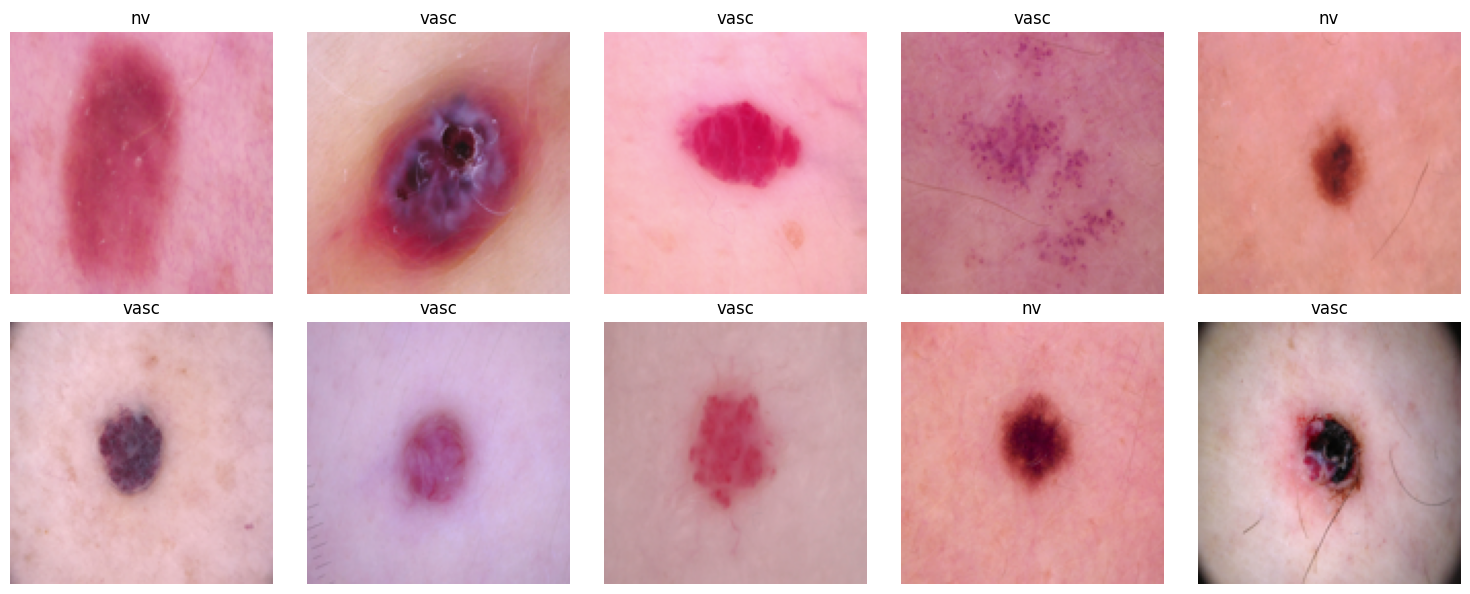

In [3]:
# Quick dataset analysis and samples
print('Total images:', len(df))
print('Class counts: ', df['label'].value_counts())

# Show a few sample images
sample = df.sample(min(10, len(df)), random_state=RANDOM_STATE)
cols = 5
rows = len(sample) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
for ax in axes[len(sample):]:
    ax.axis('off')
for i, (_, r) in enumerate(sample.iterrows()):
    img = Image.open(r['path']).convert('RGB')
    ax = axes[i]
    ax.imshow(img.resize((128,128)))
    ax.set_title(r['label'])
    ax.axis('off')
plt.tight_layout()

In [4]:
# Prepare data for a raw-pixel baseline
IMG_SIZE = (64,64)  # small for a baseline SVM
def load_image_array(path, size=IMG_SIZE):
    with Image.open(path) as im:
        im = im.convert('RGB').resize(size)
        arr = np.array(im).astype(np.float32) / 255.0
    return arr

X = np.stack([load_image_array(p) for p in df['path']])
y = df['label_id'].values
print('X shape (N,H,W,C):', X.shape)
# Flatten to vectors for a classical SVM
X_flat = X.reshape((X.shape[0], -1))
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print('Train/test split:', X_train.shape, X_test.shape)

X shape (N,H,W,C): (284, 64, 64, 3)
Train/test split: (227, 12288) (57, 12288)


              precision    recall  f1-score   support

          nv       0.96      0.86      0.91        29
        vasc       0.87      0.96      0.92        28

    accuracy                           0.91        57
   macro avg       0.92      0.91      0.91        57
weighted avg       0.92      0.91      0.91        57



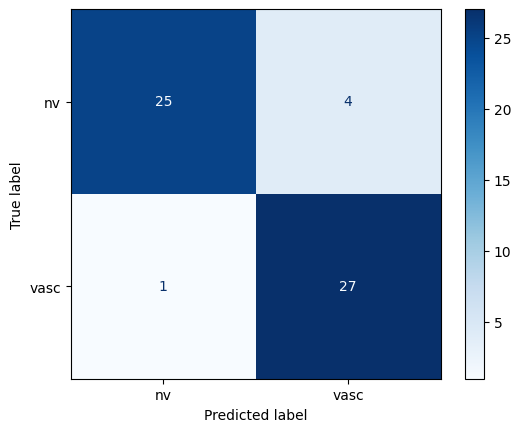

In [5]:
# Train a baseline SVM and report results
clf = SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
labels = df['label'].astype('category').cat.categories
print(classification_report(y_test, y_pred, target_names=labels))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.show()

## Preprocessing and segmentation
We apply a light artifact reduction + color normalization pipeline, then create a coarse lesion mask using Otsu thresholding on the corrected grayscale image. This is a practical baseline that keeps preprocessing explainable without extra dependencies.

Pipeline:
- Median filter to suppress thin hair-like artifacts.
- Gray-world color constancy and percentile contrast stretch.
- Otsu threshold on grayscale, with simple morphology to clean the mask.

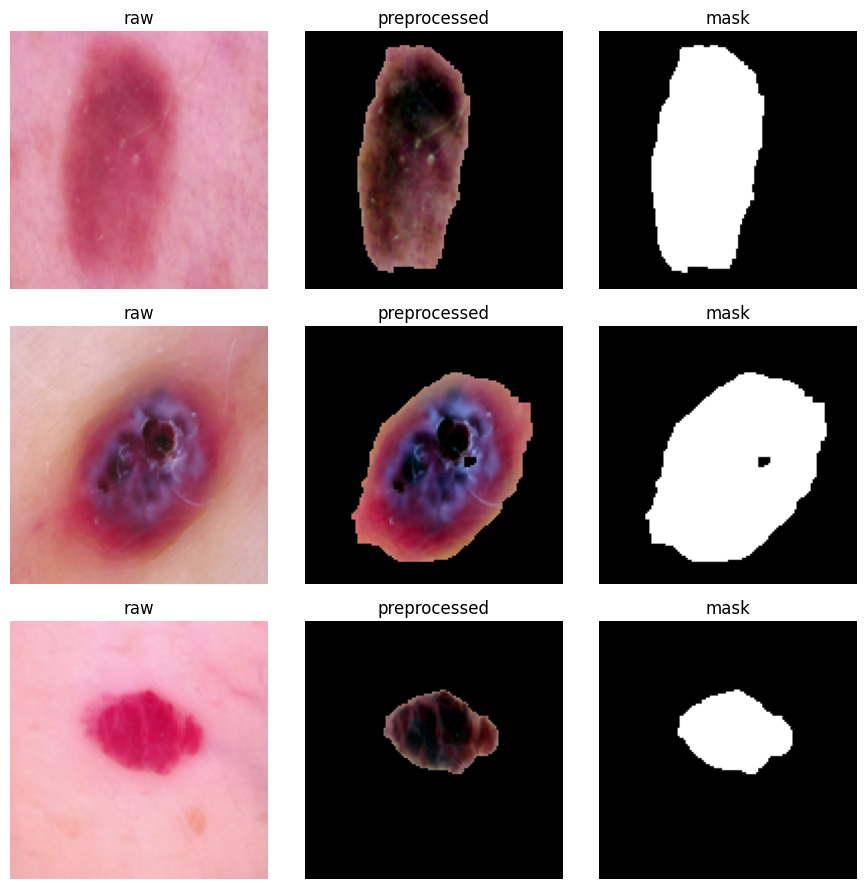

In [6]:
# Preprocessing helpers
from PIL import ImageFilter

def gray_world_balance(img):
    means = img.reshape(-1, 3).mean(axis=0)
    mean_all = means.mean()
    scale = mean_all / (means + 1e-8)
    balanced = img * scale
    return np.clip(balanced, 0.0, 1.0)

def contrast_stretch(img, lo=1, hi=99):
    out = img.copy()
    for c in range(3):
        p_lo, p_hi = np.percentile(out[..., c], [lo, hi])
        if p_hi - p_lo < 1e-6:
            continue
        out[..., c] = (out[..., c] - p_lo) / (p_hi - p_lo)
    return np.clip(out, 0.0, 1.0)

def otsu_threshold(gray):
    hist, _ = np.histogram(gray.ravel(), bins=256, range=(0.0, 1.0))
    hist = hist.astype(np.float64)
    prob = hist / (hist.sum() + 1e-12)
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * np.linspace(0.0, 1.0, 256))
    mu_t = mu[-1]
    sigma_b = (mu_t * omega - mu) ** 2 / (omega * (1.0 - omega) + 1e-12)
    idx = np.nanargmax(sigma_b)
    return idx / 255.0

def binary_erode(mask):
    mask = mask.astype(np.uint8)
    padded = np.pad(mask, 1, mode='constant', constant_values=0)
    eroded = np.ones_like(mask, dtype=np.uint8)
    h, w = mask.shape
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            eroded = np.minimum(eroded, padded[1+dy:1+dy+h, 1+dx:1+dx+w])
    return eroded.astype(bool)

def binary_dilate(mask):
    mask = mask.astype(np.uint8)
    padded = np.pad(mask, 1, mode='constant', constant_values=0)
    dilated = np.zeros_like(mask, dtype=np.uint8)
    h, w = mask.shape
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            dilated = np.maximum(dilated, padded[1+dy:1+dy+h, 1+dx:1+dx+w])
    return dilated.astype(bool)

def clean_mask(mask):
    # Open then close to reduce noise
    mask = binary_dilate(binary_erode(mask))
    mask = binary_erode(binary_dilate(mask))
    return mask

def preprocess_image(path, size=(128, 128)):
    with Image.open(path) as im:
        im = im.convert('RGB')
        im = im.filter(ImageFilter.MedianFilter(size=3))
        im = im.resize(size)
        img = np.array(im).astype(np.float32) / 255.0
    img = gray_world_balance(img)
    img = contrast_stretch(img)
    gray = img.mean(axis=2)
    thresh = otsu_threshold(gray)
    mask = gray < thresh
    if mask.mean() > 0.6:
        mask = ~mask
    mask = clean_mask(mask)
    img_seg = img * mask[..., None]
    return img, img_seg, mask

# Preview preprocessing on a few samples
preview = df.sample(min(3, len(df)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(len(preview), 3, figsize=(9, 3 * len(preview)))
if len(preview) == 1:
    axes = np.expand_dims(axes, axis=0)
for i, (_, r) in enumerate(preview.iterrows()):
    raw = Image.open(r['path']).convert('RGB').resize((128, 128))
    img, img_seg, mask = preprocess_image(r['path'], size=(128, 128))
    axes[i, 0].imshow(raw)
    axes[i, 0].set_title('raw')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(img_seg)
    axes[i, 1].set_title('preprocessed')
    axes[i, 1].axis('off')
    axes[i, 2].imshow(mask, cmap='gray')
    axes[i, 2].set_title('mask')
    axes[i, 2].axis('off')
plt.tight_layout()

## Feature extraction
We extract a compact feature vector that captures color, texture, and shape:
- HSV histograms (color distribution is informative for vascular patterns).
- Local Binary Pattern histogram (texture/vascular structure).
- Shape metrics from the mask (area, perimeter, compactness, eccentricity).
- Intensity statistics inside the lesion.

In [7]:
# Feature extraction helpers
def hsv_hist_features(img, bins=(16, 8, 8)):
    hsv = Image.fromarray((img * 255).astype(np.uint8)).convert('HSV')
    hsv = np.array(hsv).astype(np.float32)
    h = hsv[..., 0]
    s = hsv[..., 1]
    v = hsv[..., 2]
    h_hist = np.histogram(h, bins=bins[0], range=(0, 255), density=True)[0]
    s_hist = np.histogram(s, bins=bins[1], range=(0, 255), density=True)[0]
    v_hist = np.histogram(v, bins=bins[2], range=(0, 255), density=True)[0]
    return np.concatenate([h_hist, s_hist, v_hist])

def lbp_hist(gray):
    g = (gray * 255).astype(np.uint8)
    center = g[1:-1, 1:-1]
    lbp = np.zeros_like(center, dtype=np.uint8)
    lbp |= ((g[1:-1, 2:] >= center).astype(np.uint8) << 0)
    lbp |= ((g[:-2, 2:] >= center).astype(np.uint8) << 1)
    lbp |= ((g[:-2, 1:-1] >= center).astype(np.uint8) << 2)
    lbp |= ((g[:-2, :-2] >= center).astype(np.uint8) << 3)
    lbp |= ((g[1:-1, :-2] >= center).astype(np.uint8) << 4)
    lbp |= ((g[2:, :-2] >= center).astype(np.uint8) << 5)
    lbp |= ((g[2:, 1:-1] >= center).astype(np.uint8) << 6)
    lbp |= ((g[2:, 2:] >= center).astype(np.uint8) << 7)
    hist = np.histogram(lbp.ravel(), bins=256, range=(0, 256), density=True)[0]
    return hist

def shape_features(mask):
    if mask.sum() == 0:
        return np.zeros(6, dtype=np.float32)
    ys, xs = np.where(mask)
    area = float(mask.sum())
    boundary = mask & ~binary_erode(mask)
    perimeter = float(boundary.sum())
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    bbox_area = float((y1 - y0 + 1) * (x1 - x0 + 1))
    aspect = (x1 - x0 + 1) / (y1 - y0 + 1)
    extent = area / bbox_area
    ys_c = ys - ys.mean()
    xs_c = xs - xs.mean()
    cov = np.cov(np.vstack([ys_c, xs_c]))
    eig = np.sort(np.linalg.eigvals(cov))
    ecc = 0.0
    if eig[1] > 0:
        ecc = float(np.sqrt(1.0 - eig[0] / eig[1]))
    compact = (perimeter ** 2) / (area + 1e-8)
    return np.array([area, perimeter, aspect, extent, compact, ecc], dtype=np.float32)

def intensity_features(gray, mask):
    if mask.sum() == 0:
        return np.zeros(2, dtype=np.float32)
    vals = gray[mask]
    return np.array([vals.mean(), vals.std()], dtype=np.float32)

def extract_features(path, size=(128, 128)):
    img, img_seg, mask = preprocess_image(path, size=size)
    gray = img_seg.mean(axis=2)
    feats = [
        hsv_hist_features(img_seg),
        lbp_hist(gray),
        shape_features(mask),
        intensity_features(gray, mask),
    ]
    return np.concatenate(feats)

# Sanity check feature length
feat_example = extract_features(df['path'].iloc[0])
print('Feature length:', feat_example.shape[0])

Feature length: 296


## SVM with engineered features
We now build a feature matrix, split into train/validation/test, and train an SVM using the engineered features for a more interpretable classical baseline.

Validation report:
              precision    recall  f1-score   support

          nv       0.86      0.90      0.88        21
        vasc       0.90      0.86      0.88        22

    accuracy                           0.88        43
   macro avg       0.88      0.88      0.88        43
weighted avg       0.88      0.88      0.88        43



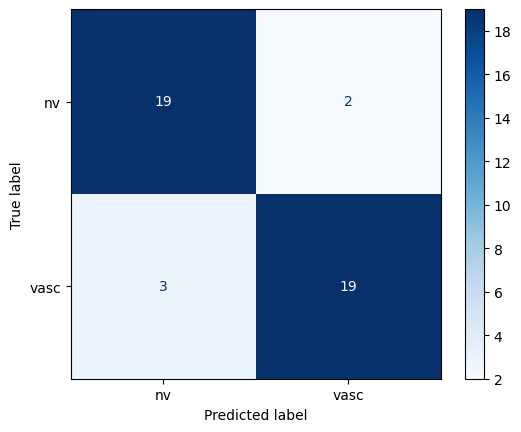

In [8]:
# Build feature matrix and train a baseline SVM
from sklearn.preprocessing import StandardScaler

X_feat = np.stack([extract_features(p) for p in df['path']])
y_feat = df['label_id'].values

X_train_f, X_temp_f, y_train_f, y_temp_f = train_test_split(
    X_feat, y_feat, test_size=0.3, stratify=y_feat, random_state=RANDOM_STATE
)
X_val_f, X_test_f, y_val_f, y_test_f = train_test_split(
    X_temp_f, y_temp_f, test_size=0.5, stratify=y_temp_f, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_fs = scaler.fit_transform(X_train_f)
X_val_fs = scaler.transform(X_val_f)
X_test_fs = scaler.transform(X_test_f)

svm_feat = SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE)
svm_feat.fit(X_train_fs, y_train_f)

val_pred = svm_feat.predict(X_val_fs)
print('Validation report:')
print(classification_report(y_val_f, val_pred, target_names=labels))

cm = confusion_matrix(y_val_f, val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.show()

## Hyperparameter tuning
We tune SVM hyperparameters using train+validation data with cross-validation to avoid leaking the final test set.

In [9]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold

X_trainval_fs = np.vstack([X_train_fs, X_val_fs])
y_trainval_f = np.concatenate([y_train_f, y_val_f])

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1.0],
    'kernel': ['rbf'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = GridSearchCV(
    SVC(class_weight='balanced'),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)
search.fit(X_trainval_fs, y_trainval_f)

print('Best params:', search.best_params_)
print('Best CV f1_macro:', search.best_score_)

best_svm = search.best_estimator_

Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV f1_macro: 0.8500437480948835


## Final test evaluation and analysis
We evaluate the tuned model on the held-out test set, compute key metrics, and provide a short, data-driven interpretation of class-wise behavior.

Test report:
              precision    recall  f1-score   support

          nv       0.79      0.86      0.83        22
        vasc       0.84      0.76      0.80        21

    accuracy                           0.81        43
   macro avg       0.82      0.81      0.81        43
weighted avg       0.82      0.81      0.81        43



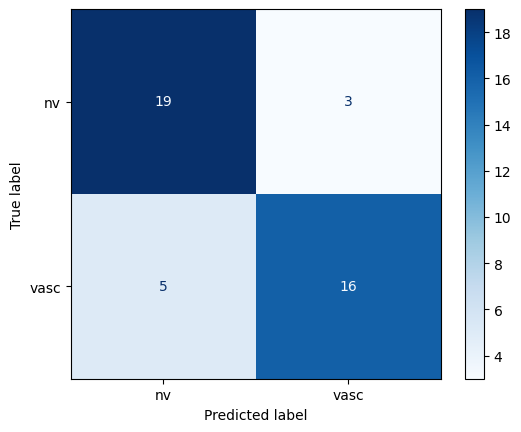

ROC-AUC: 0.8701298701298701
Class nv - precision=0.792, recall=0.864, f1=0.826, support=22
Class vasc - precision=0.842, recall=0.762, f1=0.800, support=21
Recall gap suggests class vasc is harder to detect; consider stronger segmentation or texture features.


In [10]:
# Final evaluation on the test set
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

test_pred = best_svm.predict(X_test_fs)
print('Test report:')
print(classification_report(y_test_f, test_pred, target_names=labels))

cm = confusion_matrix(y_test_f, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.show()

# ROC-AUC (binary)
if hasattr(best_svm, 'decision_function'):
    scores = best_svm.decision_function(X_test_fs)
    if scores.ndim > 1:
        scores = scores[:, 1]
else:
    scores = best_svm.predict_proba(X_test_fs)[:, 1]
roc_auc = roc_auc_score(y_test_f, scores)
print('ROC-AUC:', roc_auc)

# Short critical analysis
prec, rec, f1, support = precision_recall_fscore_support(y_test_f, test_pred)
cls_names = list(labels)
for i, cls_name in enumerate(cls_names):
    print(f'Class {cls_name} - precision={prec[i]:.3f}, recall={rec[i]:.3f}, f1={f1[i]:.3f}, support={support[i]}')

if abs(rec[0] - rec[1]) > 0.1:
    worst = cls_names[int(np.argmin(rec))]
    print('Recall gap suggests class', worst, 'is harder to detect; consider stronger segmentation or texture features.')
else:
    print('Recall is balanced; remaining errors likely stem from subtle color/texture overlap or noisy masks.')